In [ ]:
#THIS IS FOR DECONTAM  BUILDING ALPHA DIVERSITY METRICS FOR PLOTTING
# raw = pd.read_csv("/content/zotutab_decontam_Final.csv", header=None)
# D_alpha_df = pd.DataFrame(records)
# D_alpha_df.to_csv("alpha_diversity_DECONTAM.csv", index=False)

import pandas as pd
import numpy as np

# ============================
# LOAD WITH NO HEADER
# ============================
raw = pd.read_csv("/content/zotutab_decontam_Final.csv", header=None)

# Row 0 = anatomy
anatomy_row = raw.iloc[0]

# Row 1 = actual column names
header = raw.iloc[1]
df = raw.iloc[2:].copy()
df.columns = header

# Reset index cleanly
df.reset_index(drop=True, inplace=True)

# ============================
# IDENTIFY COLUMNS
# ============================
zotu_col = df.columns[0]
taxonomy_cols = df.columns[-7:]
sample_cols = df.columns[1:-7]

# ============================
# BUILD ANATOMY MAP
# ============================
anatomy_map = {
    sample_cols[i]: anatomy_row[i+1]
    for i in range(len(sample_cols))
}

# ============================
# NUMERIC CONVERSION
# ============================
df[sample_cols] = df[sample_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# ============================
# HELPER FUNCTIONS
# ============================
def compute_alpha(counts):
    counts = counts[counts > 0]
    if len(counts) == 0:
        return 0,0,0,0
    N = counts.sum()
    p = counts / N
    shannon = -np.sum(p * np.log(p))
    simpson = 1 - np.sum(p**2)
    richness = len(counts)
    evenness = shannon/np.log(richness) if richness>1 else 0
    return shannon, simpson, evenness, richness

def get_field(sample):
    if sample.startswith("MF"): return "Mesquite Flat"
    if sample.startswith("ED"): return "Eureka"
    if sample.startswith("IX"): return "Ibex"
    return "Other"

def simplify_anatomy(a):
    if pd.isna(a): return "Unknown"
    a = str(a).lower()
    if "stoss" in a: return "Stoss"
    if "lee" in a: return "Lee"
    if "interdune" in a: return "Interdune"
    return "Other"

# ============================
# ALPHA DIVERSITY
# ============================
records = []

for sample in sample_cols:
    counts = df[sample].values.astype(float)
    shannon, simpson, evenness, richness = compute_alpha(counts)

    records.append({
        "Sample": sample,
        "Field": get_field(sample),
        "Anatomy": simplify_anatomy(anatomy_map[sample]),
        "Shannon": shannon,
        "Simpson": simpson,
        "Evenness": evenness,
        "Richness": richness
    })

D_alpha_df = pd.DataFrame(records)
D_alpha_df.to_csv("alpha_diversity_DECONTAM.csv", index=False)
print("Alpha diversity saved")


Alpha diversity saved


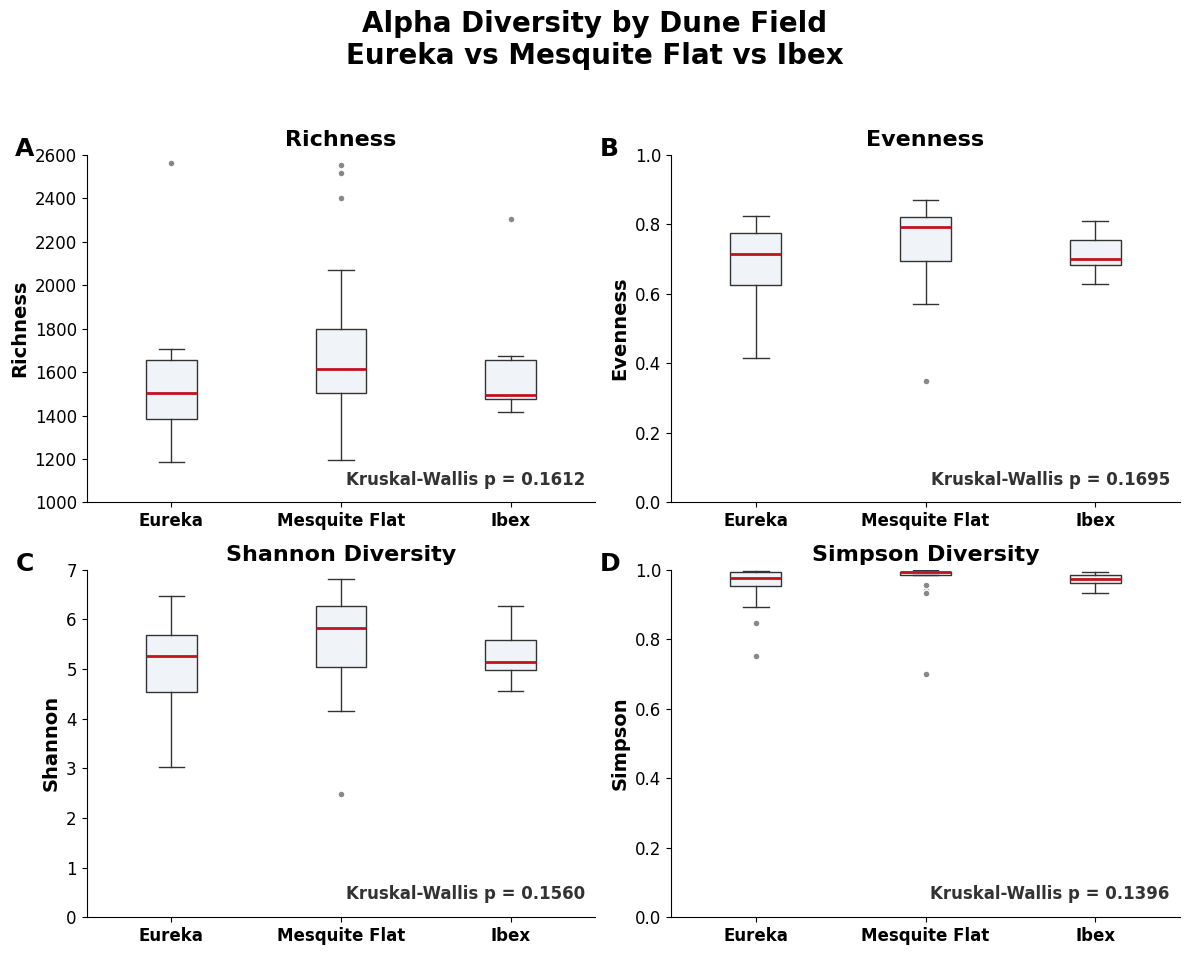

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import kruskal

# ============================
# GROUPS
# ============================
x = ["Eureka", "Mesquite Flat", "Ibex"]

y1 = [D_alpha_df[D_alpha_df["Field"] == f]["Shannon"]  for f in x]
y2 = [D_alpha_df[D_alpha_df["Field"] == f]["Simpson"]  for f in x]
y3 = [D_alpha_df[D_alpha_df["Field"] == f]["Evenness"] for f in x]
y4 = [D_alpha_df[D_alpha_df["Field"] == f]["Richness"] for f in x]

# ============================
# KRUSKAL-WALLIS TESTS
# ============================
p_shannon = kruskal(*y1).pvalue
p_simpson = kruskal(*y2).pvalue
p_even    = kruskal(*y3).pvalue
p_rich    = kruskal(*y4).pvalue

# ============================
# FIGURE
# order: Richness (A), Evenness (B), Shannon (C), Simpson (D)
# ============================
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.patch.set_facecolor("white")
fig.suptitle(
    "Alpha Diversity by Dune Field\nEureka vs Mesquite Flat vs Ibex",
    fontsize=20, fontweight="bold"
)

def box(ax, data, title, ylabel, p, panel_label, ylim=None):

    bp = ax.boxplot(
        data,
        tick_labels=x,
        patch_artist=True,
        boxprops=dict(facecolor="#f0f4f8", color="#333333"),
        medianprops=dict(color="#c1121f", linewidth=2),
        whiskerprops=dict(color="#333333"),
        capprops=dict(color="#333333"),
        flierprops=dict(marker="o", markerfacecolor="#888888",
                        markersize=5, linestyle="none",
                        markeredgecolor="white")
    )

    # panel label A/B/C/D
    ax.text(-0.14, 1.05, panel_label,
            transform=ax.transAxes,
            fontsize=18, fontweight="bold",
            va="top", ha="left")

    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=14, fontweight="bold")
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)
    plt.setp(ax.get_xticklabels(), fontweight="bold")

    if ylim is not None:
        ax.set_ylim(ylim)

    ax.text(
        0.98, 0.04,
        f"Kruskal-Wallis p = {p:.4f}",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=12, fontweight="bold",
        color="#333333"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ============================
# DRAW PANELS
# A = Richness, B = Evenness, C = Shannon, D = Simpson
# ============================
box(axs[0,0], y4, "Richness",         "Richness", p_rich,    "A", (1000, 2600))
box(axs[0,1], y3, "Evenness",         "Evenness", p_even,    "B", (0, 1))
box(axs[1,0], y1, "Shannon Diversity","Shannon",  p_shannon, "C", (0, 7))
box(axs[1,1], y2, "Simpson Diversity","Simpson",  p_simpson, "D", (0, 1))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()


In [ ]:
!pip install scikit-posthocs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 1.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import scikit_posthocs as sp
from scipy.stats import kruskal

# ============================
# LOAD FILE
# ============================
df = pd.read_csv("/content/alpha_diversity_DECONTAM.csv")

# ============================
# KRUSKAL-WALLIS FIRST
# ============================
metrics = ['Shannon', 'Simpson', 'Evenness', 'Richness']

print("=" * 55)
print("KRUSKAL-WALLIS RESULTS")
print("=" * 55)

significant = []

for metric in metrics:
    groups = [df[df['Field'] == f][metric] for f in df['Field'].unique()]
    stat, p = kruskal(*groups)
    sig = "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"{metric:<12}: H = {stat:.3f}  p = {p:.4f}  {sig}")
    if p < 0.05:
        significant.append(metric)

# ============================
# DUNN POST-HOC (significant metrics only)
# ============================
print("\n" + "=" * 55)
print("DUNN POST-HOC TEST (FDR corrected, significant metrics only)")
print("=" * 55)

for metric in significant:
    print(f"\n--- {metric} ---")
    result = sp.posthoc_dunn(
        df,
        val_col=metric,
        group_col='Field',
         p_adjust='fdr_bh'
    )
    print(result.round(4))

    print(f"\nSignificant pairs (p < 0.05):")
    printed = set()
    for col in result.columns:
        for row in result.index:
            pair = tuple(sorted([row, col]))
            if row != col and result.loc[row, col] < 0.05 and pair not in printed:
                print(f"  {row} vs {col}: p = {result.loc[row, col]:.4f}")
                printed.add(pair)

KRUSKAL-WALLIS RESULTS
Shannon     : H = 3.716  p = 0.1560  ns
Simpson     : H = 3.938  p = 0.1396  ns
Evenness    : H = 3.549  p = 0.1695  ns
Richness    : H = 3.650  p = 0.1612  ns

DUNN POST-HOC TEST (FDR corrected, significant metrics only)


In [ ]:
# ---------- DOMAIN-SPECIFIC ALPHA ----------

import pandas as pd
import numpy as np

path = "/content/zotutab_decontam_Final.csv"

# ---------- LOAD RAW ----------
raw = pd.read_csv(path, header=None)

# Row 1 = real header, rows 2+ = data
df = raw.iloc[2:].copy()
df.columns = raw.iloc[1]
df.reset_index(drop=True, inplace=True)

# ---------- COLUMN POSITIONS ----------
zotu_col = df.columns[0]
taxonomy_cols = df.columns[-7:]
sample_cols = df.columns[1:-7]

# ---------- NUMERIC COUNTS ----------
df[sample_cols] = df[sample_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# ---------- HELPER ----------
def compute_alpha(counts):
    counts = counts[counts > 0]
    if len(counts) == 0:
        return 0,0,0,0
    N = counts.sum()
    p = counts / N
    shannon = -np.sum(p * np.log(p))
    simpson = 1 - np.sum(p**2)
    richness = len(counts)
    evenness = shannon/np.log(richness) if richness>1 else 0
    return shannon, simpson, evenness, richness

# ---------- DOMAIN-SPECIFIC ALPHA ----------
records = []

for domain in df["Domain"].unique():
    sub = df[df["Domain"] == domain]

    for sample in sample_cols:
        counts = sub[sample].values.astype(float)
        shannon, simpson, evenness, richness = compute_alpha(counts)

        records.append({
            "Domain": domain,
            "Sample": sample,
            "Shannon": shannon,
            "Simpson": simpson,
            "Evenness": evenness,
            "Richness": richness
        })

D_domain_alpha_df = pd.DataFrame(records)

print("Built D_domain_alpha_df from:", path)
print(D_domain_alpha_df.head())


Built D_domain_alpha_df from: /content/zotutab_decontam_Final.csv
     Domain Sample   Shannon   Simpson  Evenness  Richness
0  bacteria  MF.4B  4.152242  0.941974  0.573804      1389
1  bacteria  MF.5B  5.615661  0.987944  0.761484      1595
2  bacteria  MF.6B  6.341947  0.994599  0.836142      1968
3  bacteria  MF.7B  6.363058  0.993703  0.819170      2363
4  bacteria  MF.8B  6.801586  0.997474  0.871432      2453


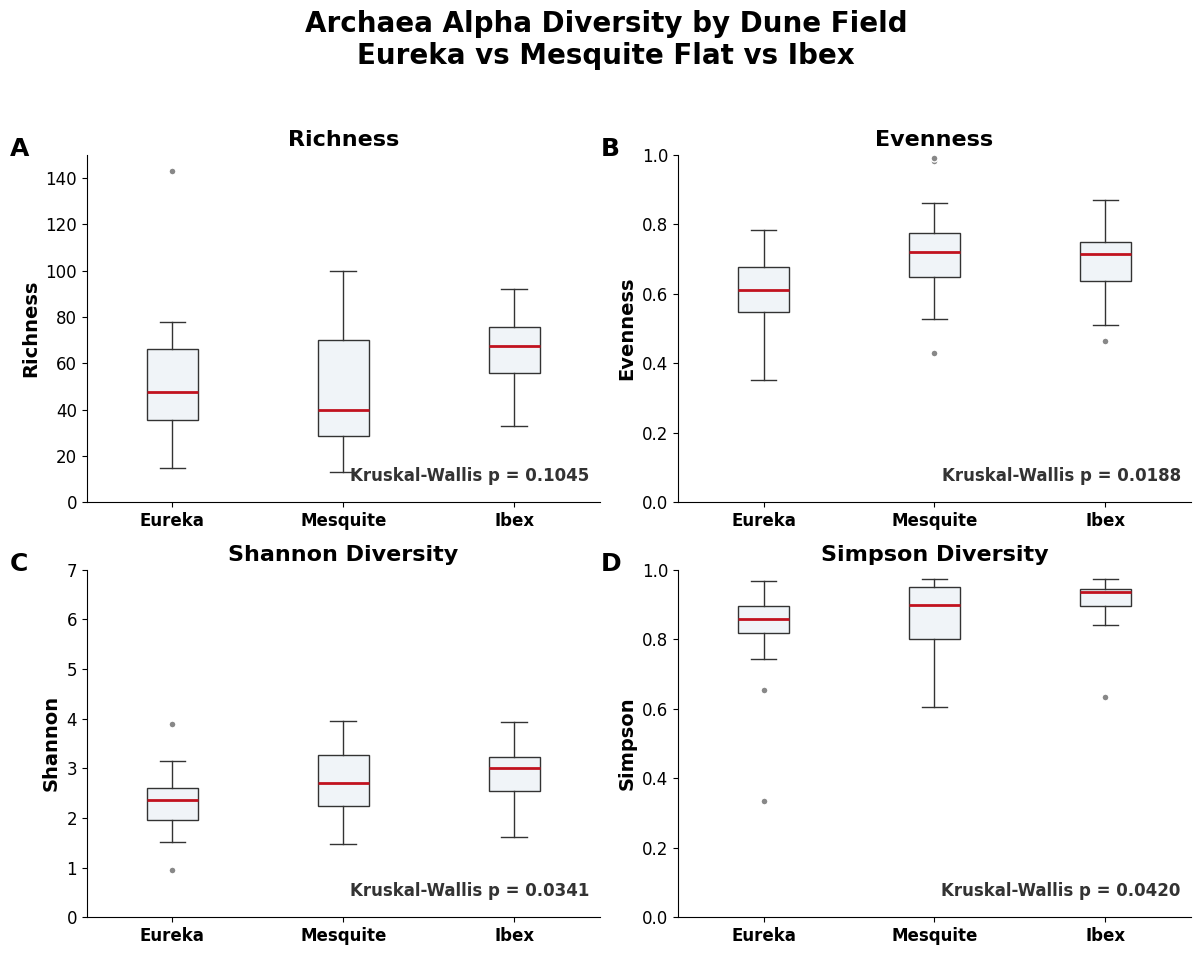

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal

# ============================
# FILTER TO ARCHAEA
# ============================
archaea_df = df[df["Domain"].str.lower() == "archaea"]

# ============================
# HELPER FUNCTIONS
# ============================
def compute_alpha(counts):
    counts = counts[counts > 0]
    if len(counts) == 0:
        return 0, 0, 0, 0
    N        = counts.sum()
    p        = counts / N
    shannon  = -np.sum(p * np.log(p))
    simpson  = 1 - np.sum(p**2)
    richness = len(counts)
    evenness = shannon / np.log(richness) if richness > 1 else 0
    return shannon, simpson, evenness, richness

def get_field(sample):
    if sample.startswith("MF"): return "Mesquite"
    if sample.startswith("ED"): return "Eureka"
    if sample.startswith("IX"): return "Ibex"
    return "Other"

# ============================
# BUILD ALPHA TABLE
# ============================
records = []
for sample in sample_cols:
    counts = archaea_df[sample].values.astype(float)
    shannon, simpson, evenness, richness = compute_alpha(counts)
    records.append({
        "Sample":   sample,
        "Field":    get_field(sample),
        "Shannon":  shannon,
        "Simpson":  simpson,
        "Evenness": evenness,
        "Richness": richness
    })

alpha_archaea = pd.DataFrame(records)

# ============================
# SAFE KRUSKAL-WALLIS
# ============================
def safe_kruskal(groups_list):
    valid = [g for g in groups_list if len(g) > 1]
    if len(valid) >= 2:
        return kruskal(*valid).pvalue
    return np.nan

# ============================
# GROUPS
# ============================
x  = ["Eureka", "Mesquite", "Ibex"]

y1 = [alpha_archaea[alpha_archaea["Field"] == f]["Shannon"]  for f in x]
y2 = [alpha_archaea[alpha_archaea["Field"] == f]["Simpson"]  for f in x]
y3 = [alpha_archaea[alpha_archaea["Field"] == f]["Evenness"] for f in x]
y4 = [alpha_archaea[alpha_archaea["Field"] == f]["Richness"] for f in x]

p_shannon = safe_kruskal(y1)
p_simpson = safe_kruskal(y2)
p_even    = safe_kruskal(y3)
p_rich    = safe_kruskal(y4)

# ============================
# FIGURE
# order: Richness (A), Evenness (B), Shannon (C), Simpson (D)
# ============================
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.patch.set_facecolor("white")
fig.suptitle(
    "Archaea Alpha Diversity by Dune Field\n"
    "Eureka vs Mesquite Flat vs Ibex",
    fontsize=20, fontweight="bold"
)

def box(ax, data, title, ylabel, p, panel_label, ylim=None):

    ax.boxplot(
        data,
        tick_labels=x,
        patch_artist=True,
        boxprops=dict(facecolor="#f0f4f8", color="#333333"),
        medianprops=dict(color="#c1121f", linewidth=2),
        whiskerprops=dict(color="#333333"),
        capprops=dict(color="#333333"),
        flierprops=dict(marker="o", markerfacecolor="#888888",
                        markersize=5, linestyle="none",
                        markeredgecolor="white")
    )

    #panel label
    ax.text(-0.15, 1.05, panel_label,
            transform=ax.transAxes,
            fontsize=18, fontweight="bold",
            va="top", ha="left")

    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=14, fontweight="bold")
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)
    plt.setp(ax.get_xticklabels(), fontweight="bold")

    if ylim is not None:
        ax.set_ylim(ylim)

    p_text = f"{p:.4f}" if not np.isnan(p) else "N/A"
    ax.text(
        0.98, 0.05,
        f"Kruskal-Wallis p = {p_text}",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=12, fontweight="bold",
        color="#333333"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ============================
# DRAW PANELS
# A = Richness, B = Evenness, C = Shannon, D = Simpson
# ============================
box(axs[0,0], y4, "Richness",         "Richness", p_rich,    "A", (0, 150))
box(axs[0,1], y3, "Evenness",         "Evenness", p_even,    "B", (0, 1))
box(axs[1,0], y1, "Shannon Diversity","Shannon",  p_shannon, "C", (0, 7))
box(axs[1,1], y2, "Simpson Diversity","Simpson",  p_simpson, "D", (0, 1))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()


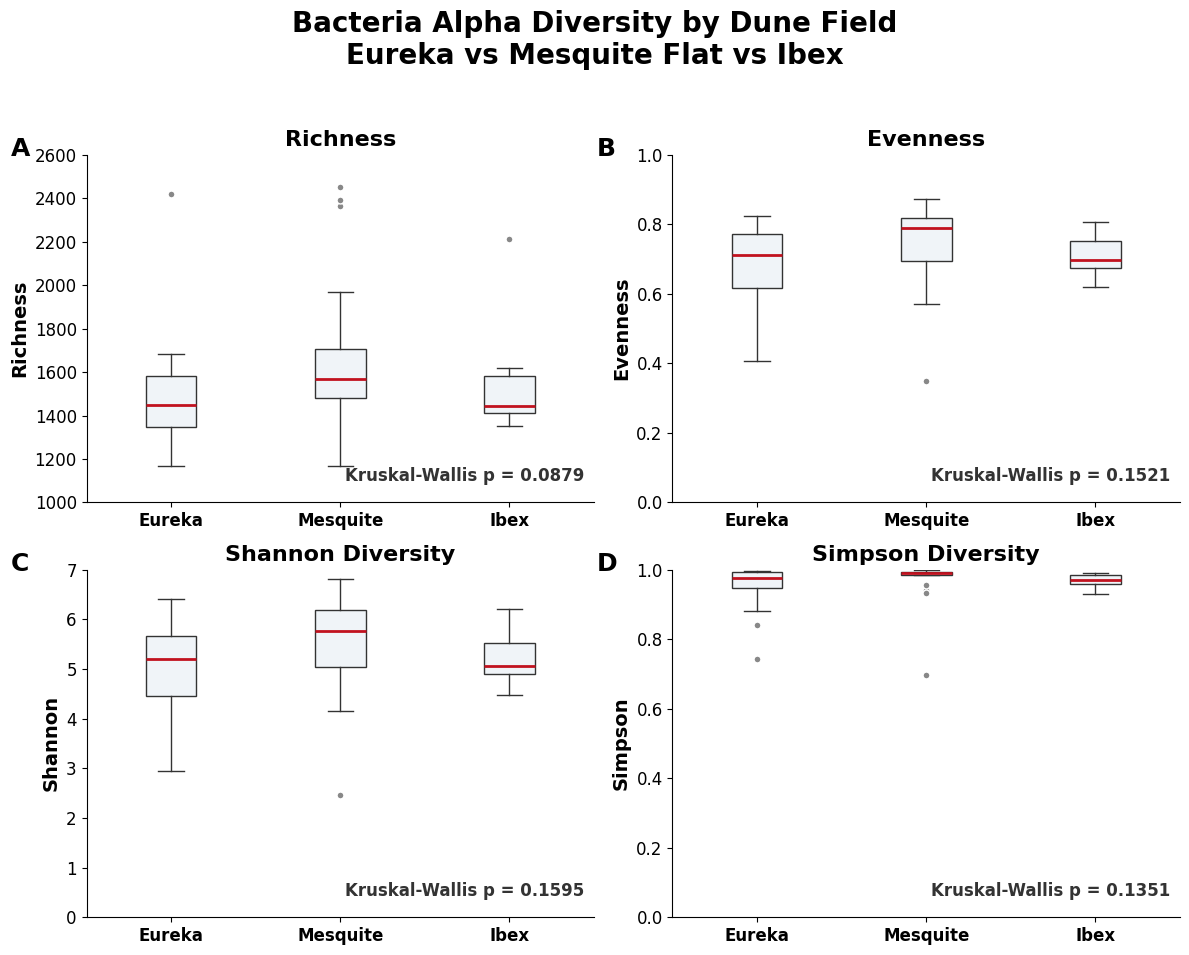

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kruskal

# ============================
# FILTER TO BACTERIA
# ============================
alpha_bact = D_domain_alpha_df[
    D_domain_alpha_df["Domain"].str.lower() == "bacteria"].copy()

alpha_bact["Field"] = alpha_bact["Sample"].apply(lambda s:
    "Mesquite" if s.startswith("MF") else
    "Eureka"   if s.startswith("ED") else
    "Ibex"     if s.startswith("IX") else "Other"
)

# ============================
# SAFE KRUSKAL-WALLIS
# ============================
def safe_kruskal(groups_list):
    valid = [g for g in groups_list if len(g) > 1]
    if len(valid) >= 2:
        return kruskal(*valid).pvalue
    return np.nan

# ============================
# GROUPS
# ============================
x  = ["Eureka", "Mesquite", "Ibex"]

y1 = [alpha_bact[alpha_bact["Field"] == f]["Shannon"]  for f in x]
y2 = [alpha_bact[alpha_bact["Field"] == f]["Simpson"]  for f in x]
y3 = [alpha_bact[alpha_bact["Field"] == f]["Evenness"] for f in x]
y4 = [alpha_bact[alpha_bact["Field"] == f]["Richness"] for f in x]

p_shannon = safe_kruskal(y1)
p_simpson = safe_kruskal(y2)
p_even    = safe_kruskal(y3)
p_rich    = safe_kruskal(y4)

# ============================
# FIGURE
# A = Richness, B = Evenness, C = Shannon, D = Simpson
# ============================
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.patch.set_facecolor("white")
fig.suptitle(
    "Bacteria Alpha Diversity by Dune Field\n"
    "Eureka vs Mesquite Flat vs Ibex",
    fontsize=20, fontweight="bold"
)

def box(ax, data, title, ylabel, p, panel_label, ylim=None):

    ax.boxplot(
        data,
        tick_labels=x,
        patch_artist=True,
        boxprops=dict(facecolor="#f0f4f8", color="#333333"),
        medianprops=dict(color="#c1121f", linewidth=2),
        whiskerprops=dict(color="#333333"),
        capprops=dict(color="#333333"),
        flierprops=dict(marker="o", markerfacecolor="#888888",
                        markersize=5, linestyle="none",
                        markeredgecolor="white")
    )

    # panel label
    ax.text(-0.15, 1.05, panel_label,
            transform=ax.transAxes,
            fontsize=18, fontweight="bold",
            va="top", ha="left")

    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=14, fontweight="bold")
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)
    plt.setp(ax.get_xticklabels(), fontweight="bold")

    if ylim is not None:
        ax.set_ylim(ylim)

    p_text = f"{p:.4f}" if not np.isnan(p) else "N/A"
    ax.text(
        0.98, 0.05,
        f"Kruskal-Wallis p = {p_text}",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=12, fontweight="bold",
        color="#333333"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ============================
# DRAW PANELS
# ============================
box(axs[0,0], y4, "Richness",         "Richness", p_rich,    "A", (1000, 2600))
box(axs[0,1], y3, "Evenness",         "Evenness", p_even,    "B", (0, 1))
box(axs[1,0], y1, "Shannon Diversity","Shannon",  p_shannon, "C", (0, 7))
box(axs[1,1], y2, "Simpson Diversity","Simpson",  p_simpson, "D", (0, 1))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()


In [ ]:
!pip install scikit-bio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 20.2 MB/s eta 0:00:00


Samples: 52
PCo1: 14.5%  PCo2: 9.2%


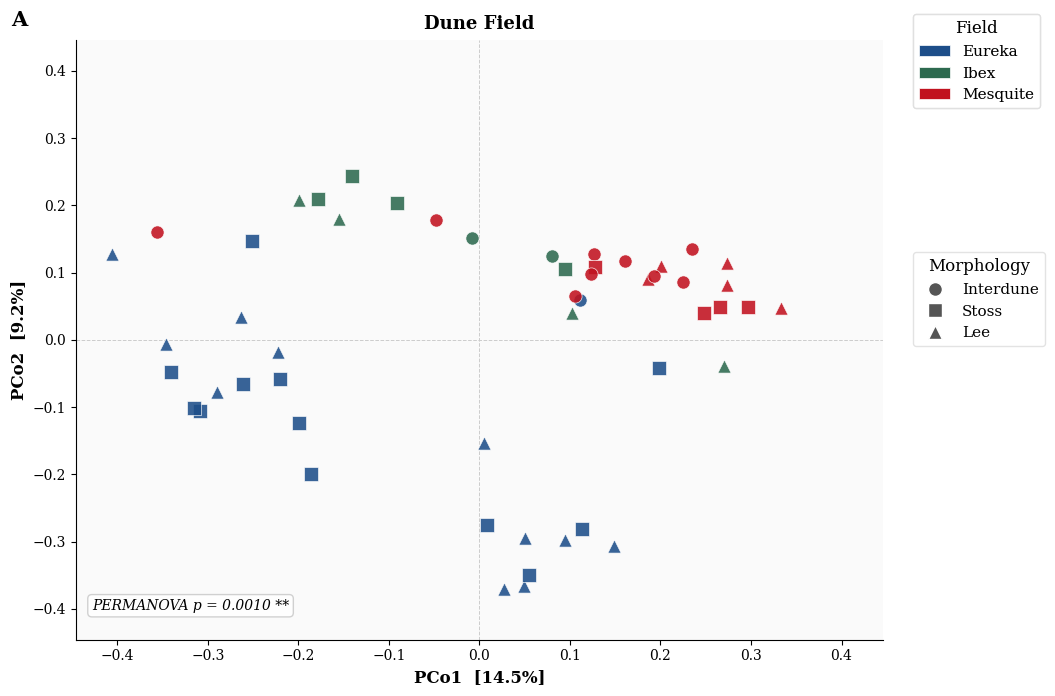

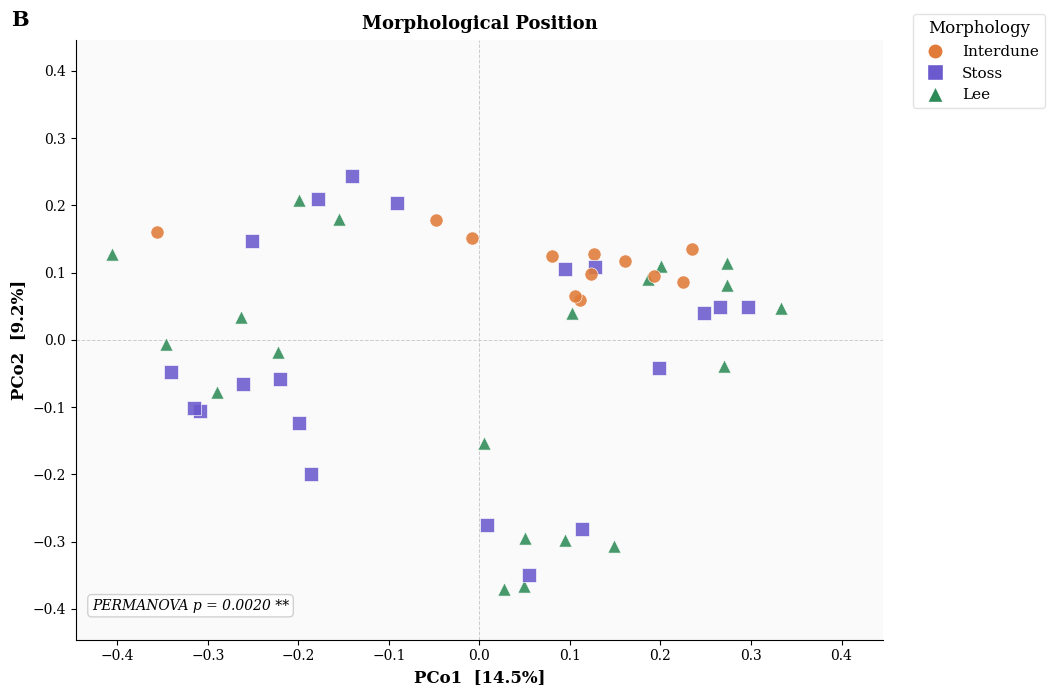

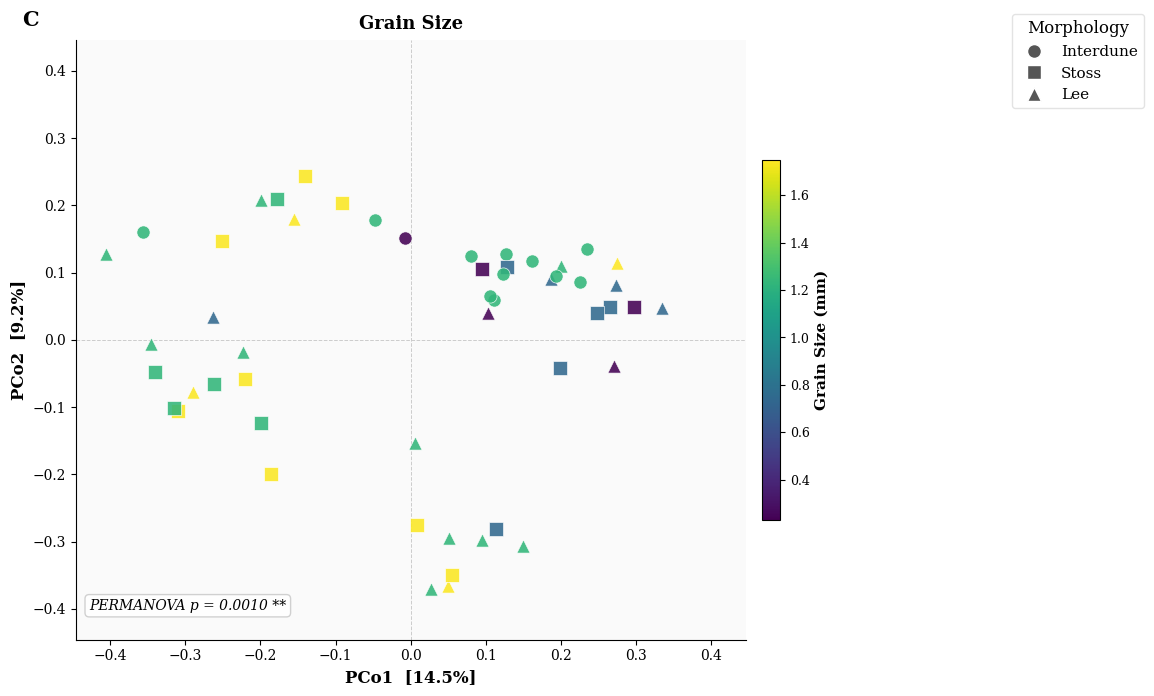

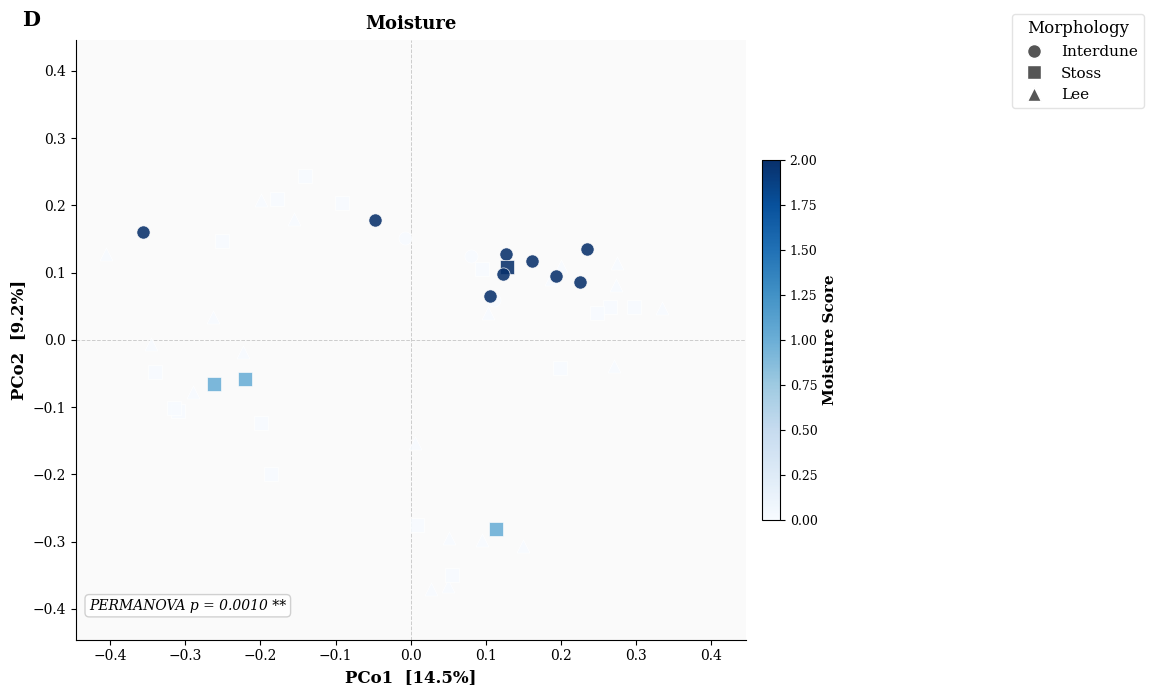

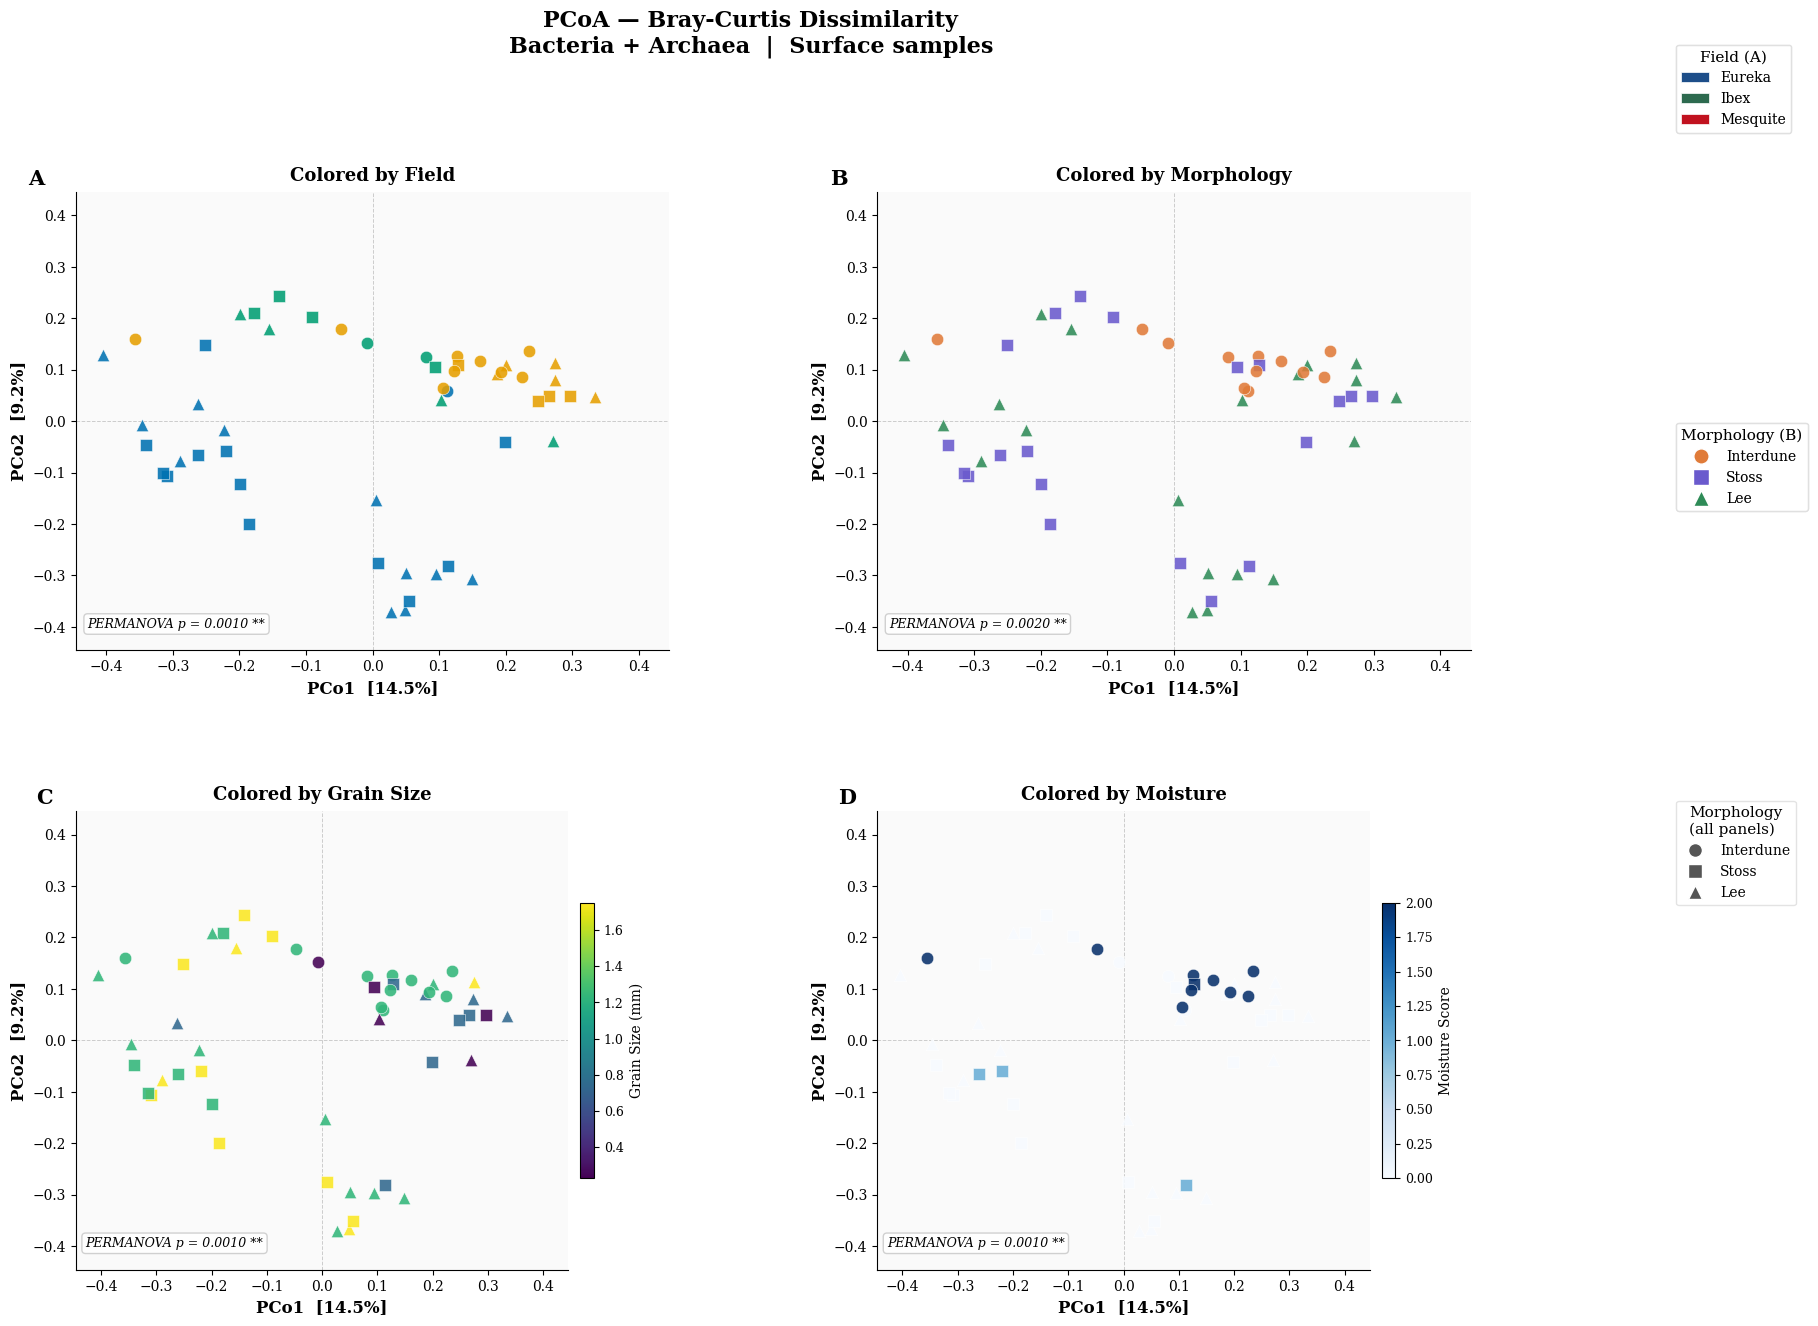

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from scipy.spatial.distance import pdist, squareform
from skbio import DistanceMatrix
from skbio.stats.distance import permanova
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

# ============================
# LOAD DATA
# ============================
def load_otu(path):
    raw = pd.read_csv(path, header=None)
    first_val = str(raw.iloc[0, 0]).strip().upper()
    if first_val == "ANATOMY":
        header_row = 1
        data_start = 2
    else:
        header_row = 0
        data_start = 1

    df = raw.iloc[data_start:].copy()
    df.columns = raw.iloc[header_row].values
    df.reset_index(drop=True, inplace=True)

    n_tax     = 7
    tax_cols  = list(df.columns[-n_tax:])
    samp_cols = [c for c in df.columns[1:]
                 if c not in tax_cols
                 and "Blank" not in str(c)]

    for col in samp_cols:
        df[col] = pd.to_numeric(df[col],
                                errors="coerce").fillna(0)

    domain_col = tax_cols[0]
    df[domain_col] = (df[domain_col].astype(str)
                      .str.strip().str.lower())
    micro = df[df[domain_col].isin(
        ["bacteria", "archaea"])].copy()

    return pd.DataFrame(
        micro[samp_cols].values.T,
        index=samp_cols,
        columns=micro[micro.columns[0]]
    )

otu  = load_otu("/content/zotutab_decontam_Final.csv")
meta = pd.read_csv("/content/PERM_metadata.csv").rename(
           columns={"Sample Name:": "SampleID"})
meta["SampleID"] = meta["SampleID"].str.strip()
meta = meta.set_index("SampleID")

shared   = sorted(set(otu.index) & set(meta.index))
otu      = otu.loc[shared]
meta_aln = meta.loc[shared].copy()
meta_aln["Morphology"] = meta_aln["Morphology"].str.strip()

for c in ["GrainSize", "Moisture"]:
    meta_aln[c] = pd.to_numeric(meta_aln[c],
                                 errors="coerce")
meta_aln[["GrainSize","Moisture"]] = meta_aln[
    ["GrainSize","Moisture"]].fillna(
    meta_aln[["GrainSize","Moisture"]].median())

print(f"Samples: {len(shared)}")

# ============================
# BRAY-CURTIS + PCoA
# ============================
arr    = otu.values.astype(float)
ids    = list(otu.index)
bc_arr = squareform(pdist(arr, metric="braycurtis"))

D2   = bc_arr ** 2
B    = -0.5 * (D2 - D2.mean(1, keepdims=True)
                   - D2.mean(0, keepdims=True) + D2.mean())
ev, evec = np.linalg.eigh(B)
idx  = np.argsort(ev)[::-1]
ev   = ev[idx]; evec = evec[:, idx]
pos  = ev > 0
coords = evec[:, pos] * np.sqrt(ev[pos])
var    = ev[pos] / ev[pos].sum() * 100

print(f"PCo1: {var[0]:.1f}%  PCo2: {var[1]:.1f}%")

# ============================
# METADATA ARRAYS
# ============================
def get_field(s):
    if str(s).startswith("MF"): return "Mesquite"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX"): return "Ibex"
    return "Other"

def simplify_morph(m):
    m = str(m).strip()
    if "Stoss" in m: return "Stoss"
    if "Lee"   in m: return "Lee"
    return "Interdune"

fields      = [get_field(s) for s in shared]
morphs      = [simplify_morph(
    meta_aln.loc[s, "Morphology"]
    if s in meta_aln.index else "Interdune")
    for s in shared]
grain_sizes = [meta_aln.loc[s, "GrainSize"]
               if s in meta_aln.index else np.nan
               for s in shared]
moistures   = [meta_aln.loc[s, "Moisture"]
               if s in meta_aln.index else np.nan
               for s in shared]

# ============================
# STYLES
# ============================
FIELD_COLORS = {
    "Eureka":   "#1d4e89",
    "Ibex":     "#2d6a4f",
    "Mesquite": "#c1121f"
}
MORPH_MARKERS = {
    "Interdune": "o",
    "Stoss":     "s",
    "Lee":       "^"
}

def sig_str(p):
    try:
        p = float(p)
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        return "ns"
    except:
        return ""

def get_pval(r):
    for k in ["p-value","p_value","pvalue"]:
        if k in r.index: return r[k]
    return np.nan

dm_bc = DistanceMatrix(bc_arr, ids=ids)

def base_ax(ax, title, panel_lbl):
    ax.axhline(0, color="#cccccc", lw=0.7,
               ls="--", zorder=1)
    ax.axvline(0, color="#cccccc", lw=0.7,
               ls="--", zorder=1)
    h = max(abs(coords[:,0]).max(),
            abs(coords[:,1]).max()) * 1.10
    ax.set_xlim(-h, h)
    ax.set_ylim(-h, h)
    ax.set_xlabel(f"PCo1  [{var[0]:.1f}%]",
                  fontsize=12, fontweight="bold")
    ax.set_ylabel(f"PCo2  [{var[1]:.1f}%]",
                  fontsize=12, fontweight="bold")
    ax.set_title(title, fontsize=13,
                 fontweight="bold", pad=8)
    ax.text(-0.08, 1.05, panel_lbl,
            transform=ax.transAxes,
            fontsize=15, fontweight="bold", va="top")
    ax.tick_params(labelsize=10)
    ax.set_facecolor("#fafafa")
    for sp in ["top","right"]:
        ax.spines[sp].set_visible(False)

# ============================================================
# FIGURE 1 — FIELD
# ============================================================
fig1, ax1 = plt.subplots(figsize=(9, 7))
fig1.patch.set_facecolor("white")

for i in range(len(shared)):
    fc = FIELD_COLORS.get(fields[i], "gray")
    mk = MORPH_MARKERS.get(morphs[i], "o")
    ax1.scatter(coords[i,0], coords[i,1],
                color=fc, marker=mk, s=90,
                edgecolors="white", linewidths=0.5,
                alpha=0.88, zorder=3)

# PERMANOVA
res = permanova(dm_bc,
                pd.Series(fields, index=shared,
                           name="Field"),
                permutations=999)
p_f = get_pval(res)
ax1.text(0.02, 0.05,
         f"PERMANOVA p = {p_f:.4f} {sig_str(p_f)}",
         transform=ax1.transAxes, fontsize=10,
         style="italic",
         bbox=dict(boxstyle="round,pad=0.3",
                   facecolor="white",
                   edgecolor="#cccccc", alpha=0.9))

base_ax(ax1, "Dune Field", "A")

field_handles = [
    mpatches.Patch(facecolor=c, edgecolor="white",
                   lw=0.5, label=f)
    for f, c in FIELD_COLORS.items()
]
morph_handles = [
    plt.Line2D([0],[0], marker=mk, color="w",
               markerfacecolor="#555",
               markeredgecolor="white",
               markersize=10, label=m, linewidth=0)
    for m, mk in MORPH_MARKERS.items()
]
leg1 = fig1.legend(handles=field_handles,
                    title="Field",
                    bbox_to_anchor=(1.01,0.99),
                    loc="upper left",
                    fontsize=11, title_fontsize=12,
                    frameon=True, edgecolor="#ddd")
leg2 = fig1.legend(handles=morph_handles,
                    title="Morphology",
                    bbox_to_anchor=(1.01,0.65),
                    loc="upper left",
                    fontsize=11, title_fontsize=12,
                    frameon=True, edgecolor="#ddd")
fig1.add_artist(leg1)
plt.tight_layout()

plt.show()

# ============================================================
# FIGURE 2 — MORPHOLOGY
# ============================================================
FIELD_COLORS = {
    "Eureka":   "#0072B2",  # blue
    "Mesquite": "#E69F00",  # orange
    "Ibex":     "#009E73",  # bluish green
}

fig2, ax2 = plt.subplots(figsize=(9, 7))
fig2.patch.set_facecolor("white")

for i in range(len(shared)):
    fc = MORPH_COLORS.get(morphs[i], "gray")
    mk = MORPH_MARKERS.get(morphs[i], "o")
    ax2.scatter(coords[i,0], coords[i,1],
                color=fc, marker=mk, s=90,
                edgecolors="white", linewidths=0.5,
                alpha=0.88, zorder=3)

res_m = permanova(dm_bc,
                   pd.Series(morphs, index=shared,
                              name="Morph"),
                   permutations=999)
p_m = get_pval(res_m)
ax2.text(0.02, 0.05,
         f"PERMANOVA p = {p_m:.4f} {sig_str(p_m)}",
         transform=ax2.transAxes, fontsize=10,
         style="italic",
         bbox=dict(boxstyle="round,pad=0.3",
                   facecolor="white",
                   edgecolor="#cccccc", alpha=0.9))

base_ax(ax2, "Morphological Position", "B")

morph_color_handles = [
    plt.Line2D([0],[0], marker=MORPH_MARKERS[m],
               color="w",
               markerfacecolor=MORPH_COLORS[m],
               markeredgecolor="white",
               markersize=11, label=m, linewidth=0)
    for m in ["Interdune","Stoss","Lee"]
]
fig2.legend(handles=morph_color_handles,
             title="Morphology",
             bbox_to_anchor=(1.01,0.99),
             loc="upper left",
             fontsize=11, title_fontsize=12,
             frameon=True, edgecolor="#ddd")
plt.tight_layout()

plt.show()
# ============================================================
# FIGURE 3 — GRAIN SIZE
# ============================================================
fig3, ax3 = plt.subplots(figsize=(9, 7))
fig3.patch.set_facecolor("white")

gs_vals = np.array(grain_sizes, dtype=float)
norm_gs = Normalize(vmin=np.nanmin(gs_vals),
                    vmax=np.nanmax(gs_vals))
cmap_gs = cm.get_cmap("viridis")

for i in range(len(shared)):
    fc = cmap_gs(norm_gs(gs_vals[i]))
    mk = MORPH_MARKERS.get(morphs[i], "o")
    ax3.scatter(coords[i,0], coords[i,1],
                color=fc, marker=mk, s=90,
                edgecolors="white", linewidths=0.5,
                alpha=0.88, zorder=3)

sm_gs = cm.ScalarMappable(cmap=cmap_gs, norm=norm_gs)
sm_gs.set_array([])
cbar3 = fig3.colorbar(sm_gs, ax=ax3,
                       shrink=0.6, pad=0.02)
cbar3.set_label("Grain Size (mm)", fontsize=11,
                fontweight="bold")

res_gs = permanova(dm_bc,
                    pd.Series(gs_vals, index=shared,
                               name="GrainSize"),
                    permutations=999)
p_gs = get_pval(res_gs)
ax3.text(0.02, 0.05,
         f"PERMANOVA p = {p_gs:.4f} {sig_str(p_gs)}",
         transform=ax3.transAxes, fontsize=10,
         style="italic",
         bbox=dict(boxstyle="round,pad=0.3",
                   facecolor="white",
                   edgecolor="#cccccc", alpha=0.9))

base_ax(ax3, "Grain Size", "C")

morph_handles3 = [
    plt.Line2D([0],[0], marker=mk, color="w",
               markerfacecolor="#555",
               markeredgecolor="white",
               markersize=10, label=m, linewidth=0)
    for m, mk in MORPH_MARKERS.items()
]
fig3.legend(handles=morph_handles3,
             title="Morphology",
             bbox_to_anchor=(1.12,0.99),
             loc="upper left",
             fontsize=11, title_fontsize=12,
             frameon=True, edgecolor="#ddd")
plt.tight_layout()
plt.show()

# ============================================================
# FIGURE 4 — MOISTURE
# ============================================================
fig4, ax4 = plt.subplots(figsize=(9, 7))
fig4.patch.set_facecolor("white")

mo_vals = np.array(moistures, dtype=float)
norm_mo = Normalize(vmin=np.nanmin(mo_vals),
                    vmax=np.nanmax(mo_vals))
cmap_mo = cm.get_cmap("Blues")

for i in range(len(shared)):
    fc = cmap_mo(norm_mo(mo_vals[i]))
    mk = MORPH_MARKERS.get(morphs[i], "o")
    ax4.scatter(coords[i,0], coords[i,1],
                color=fc, marker=mk, s=90,
                edgecolors="white", linewidths=0.5,
                alpha=0.88, zorder=3)

sm_mo = cm.ScalarMappable(cmap=cmap_mo, norm=norm_mo)
sm_mo.set_array([])
cbar4 = fig4.colorbar(sm_mo, ax=ax4,
                       shrink=0.6, pad=0.02)
cbar4.set_label("Moisture Score", fontsize=11,
                fontweight="bold")

res_mo = permanova(dm_bc,
                    pd.Series(mo_vals, index=shared,
                               name="Moisture"),
                    permutations=999)
p_mo = get_pval(res_mo)
ax4.text(0.02, 0.05,
         f"PERMANOVA p = {p_mo:.4f} {sig_str(p_mo)}",
         transform=ax4.transAxes, fontsize=10,
         style="italic",
         bbox=dict(boxstyle="round,pad=0.3",
                   facecolor="white",
                   edgecolor="#cccccc", alpha=0.9))

base_ax(ax4, "Moisture", "D")

morph_handles4 = [
    plt.Line2D([0],[0], marker=mk, color="w",
               markerfacecolor="#555",
               markeredgecolor="white",
               markersize=10, label=m, linewidth=0)
    for m, mk in MORPH_MARKERS.items()
]
fig4.legend(handles=morph_handles4,
             title="Morphology",
             bbox_to_anchor=(1.12,0.99),
             loc="upper left",
             fontsize=11, title_fontsize=12,
             frameon=True, edgecolor="#ddd")
plt.tight_layout()

plt.show()


# ============================================================
# FIGURE 5 — COMBINED 2x2
# ============================================================
fig5, axes = plt.subplots(2, 2, figsize=(18, 14),
    gridspec_kw={"hspace":0.35, "wspace":0.35})
fig5.patch.set_facecolor("white")

panel_data = [
    (axes[0,0], "Field",          "A"),
    (axes[0,1], "Morphology",     "B"),
    (axes[1,0], "Grain Size",     "C"),
    (axes[1,1], "Moisture",       "D"),
]

for ax, title, lbl in panel_data:
    for i in range(len(shared)):
        mk = MORPH_MARKERS.get(morphs[i], "o")

        if title == "Field":
            fc = FIELD_COLORS.get(fields[i], "gray")
        elif title == "Morphology":
            fc = MORPH_COLORS.get(morphs[i], "gray")
        elif title == "Grain Size":
            fc = cmap_gs(norm_gs(gs_vals[i]))
        else:
            fc = cmap_mo(norm_mo(mo_vals[i]))

        ax.scatter(coords[i,0], coords[i,1],
                   color=fc, marker=mk, s=80,
                   edgecolors="white", linewidths=0.4,
                   alpha=0.88, zorder=3)

    base_ax(ax, f"Colored by {title}", lbl)

    # PERMANOVA annotation
    if title == "Field":
        p_ann = p_f
    elif title == "Morphology":
        p_ann = p_m
    elif title == "Grain Size":
        p_ann = p_gs
    else:
        p_ann = p_mo

    ax.text(0.02, 0.05,
            f"PERMANOVA p = {p_ann:.4f} {sig_str(p_ann)}",
            transform=ax.transAxes, fontsize=9,
            style="italic",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="white",
                      edgecolor="#cccccc", alpha=0.9))

    # colorbars for continuous
    if title == "Grain Size":
        cbar = fig5.colorbar(
            cm.ScalarMappable(cmap=cmap_gs, norm=norm_gs),
            ax=ax, shrink=0.6, pad=0.02)
        cbar.set_label("Grain Size (mm)", fontsize=10)
    elif title == "Moisture":
        cbar = fig5.colorbar(
            cm.ScalarMappable(cmap=cmap_mo, norm=norm_mo),
            ax=ax, shrink=0.6, pad=0.02)
        cbar.set_label("Moisture Score", fontsize=10)

# legends for combined figure
leg_field = fig5.legend(
    handles=field_handles,
    title="Field (A)",
    bbox_to_anchor=(1.01, 0.99),
    loc="upper left",
    fontsize=10, title_fontsize=11,
    frameon=True, edgecolor="#ddd")

leg_morph_col = fig5.legend(
    handles=morph_color_handles,
    title="Morphology (B)",
    bbox_to_anchor=(1.01, 0.72),
    loc="upper left",
    fontsize=10, title_fontsize=11,
    frameon=True, edgecolor="#ddd")

leg_morph_sym = fig5.legend(
    handles=morph_handles,
    title="Morphology\n(all panels)",
    bbox_to_anchor=(1.01, 0.45),
    loc="upper left",
    fontsize=10, title_fontsize=11,
    frameon=True, edgecolor="#ddd")

fig5.add_artist(leg_field)
fig5.add_artist(leg_morph_col)

fig5.suptitle(
    "PCoA — Bray-Curtis Dissimilarity\n"
    "Bacteria + Archaea  |  Surface samples",
    fontsize=16, fontweight="bold", y=1.01)

plt.show()

In [3]:
import numpy as np
import pandas as pd

# ============================
# LOAD COUNT FILE
# ============================
path = "/content/zotutab_decontam_Final.csv"
raw  = pd.read_csv(path, header=None)

anatomy_row = raw.iloc[0]
header_row  = raw.iloc[1]

df = raw.iloc[2:].copy()
df.columns = header_row
df.reset_index(drop=True, inplace=True)

tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]
zotu_col = df.columns[0]

sample_cols = [c for c in df.columns
               if c not in tax_cols
               and c != zotu_col
               and "Blank" not in str(c)]

df[sample_cols] = df[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df["Domain"] = df["Domain"].str.lower().str.strip()
df["Phylum"] = df["Phylum"].str.lower().str.strip()

# ============================
# HELPER FUNCTIONS
# ============================
def compute_alpha(counts):
    counts   = counts[counts > 0]
    if len(counts) == 0:
        return 0, 0, 0, 0
    N        = counts.sum()
    p        = counts / N
    shannon  = -np.sum(p * np.log(p))
    simpson  = 1 - np.sum(p ** 2)
    richness = len(counts)
    evenness = shannon / np.log(richness) if richness > 1 else 0
    return shannon, simpson, evenness, richness

def get_field(s):
    if str(s).startswith("MF"): return "Mesquite Flat"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX"): return "Ibex"
    return "Other"

def simplify_morph(anat):
    anat = str(anat).strip()
    if "Depth" in anat: return None
    if "Stoss" in anat: return "Stoss"
    if "Lee"   in anat: return "Lee"
    return "Interdune"

# anatomy map
col_list    = list(df.columns)
anatomy_map = {}
for s in sample_cols:
    try:
        col_idx        = col_list.index(s)
        anatomy_map[s] = str(anatomy_row.iloc[col_idx]).strip()
    except:
        anatomy_map[s] = "Interdune"

# ============================
# FILTER SUBSETS
# ============================
prokaryotes = df[
    df["Domain"].isin(["bacteria", "archaea"]) &
    (df["Phylum"] != "bacteria") &
    df["Phylum"].notna()
].copy()

bacteria = df[
    (df["Domain"] == "bacteria") &
    (df["Phylum"] != "bacteria") &
    df["Phylum"].notna()
].copy()

archaea = df[df["Domain"] == "archaea"].copy()

# ============================
# COMPUTE ALPHA FOR EACH SUBSET
# ============================
def build_alpha(subset_df, label):
    records = []
    for s in sample_cols:
        morph = simplify_morph(anatomy_map.get(s, "Interdune"))
        if morph is None:
            continue  # skip depth samples
        counts                           = subset_df[s].values.astype(float)
        shannon, simpson, evenness, rich = compute_alpha(counts)
        records.append({
            "Sample":   s,
            "Field":    get_field(s),
            "Morph":    morph,
            "Richness": rich,
            "Shannon":  shannon,
            "Simpson":  simpson,
            "Evenness": evenness,
        })
    df_out = pd.DataFrame(records)
    print(f"\n{label}: {len(df_out)} samples")
    return df_out

alpha_prok = build_alpha(prokaryotes, "All prokaryotes")
alpha_bact = build_alpha(bacteria,    "Bacteria")
alpha_arch = build_alpha(archaea,     "Archaea")

# ============================
# PRINT ALL MEDIANS
# ============================
metrics = ["Richness", "Evenness", "Shannon", "Simpson"]

print("\n" + "="*60)
print("MEDIAN VALUES BY FIELD")
print("="*60)

for label, adf in [("All prokaryotes", alpha_prok),
                    ("Bacteria",        alpha_bact),
                    ("Archaea",         alpha_arch)]:
    print(f"\n{label}:")
    print(adf.groupby("Field")[metrics].median().round(3).to_string())

print("\n" + "="*60)
print("MEDIAN VALUES BY MORPHOLOGY")
print("="*60)

for label, adf in [("All prokaryotes", alpha_prok),
                    ("Bacteria",        alpha_bact),
                    ("Archaea",         alpha_arch)]:
    print(f"\n{label}:")
    print(adf.groupby("Morph")[metrics].median().round(3).to_string())


All prokaryotes: 52 samples

Bacteria: 52 samples

Archaea: 52 samples

MEDIAN VALUES BY FIELD

All prokaryotes:
               Richness  Evenness  Shannon  Simpson
Field                                              
Eureka           1505.5     0.716    5.256    0.976
Ibex             1494.5     0.701    5.143    0.973
Mesquite Flat    1615.5     0.791    5.815    0.992

Bacteria:
               Richness  Evenness  Shannon  Simpson
Field                                              
Eureka           1450.0     0.711    5.204    0.975
Ibex             1442.0     0.696    5.068    0.971
Mesquite Flat    1568.0     0.789    5.771    0.991

Archaea:
               Richness  Evenness  Shannon  Simpson
Field                                              
Eureka             47.5     0.612    2.364    0.857
Ibex               67.5     0.716    3.014    0.936
Mesquite Flat      40.0     0.721    2.709    0.897

MEDIAN VALUES BY MORPHOLOGY

All prokaryotes:
           Richness  Evenness  Shannon

In [4]:
from scipy.stats import kruskal

for label, adf in [("Bacteria", alpha_bact),
                    ("Archaea",  alpha_arch)]:
    print(f"\n{label} — KW by Morphology:")
    for metric in ["Richness","Evenness","Shannon","Simpson"]:
        groups = [adf[adf["Morph"]==m][metric]
                  for m in ["Stoss","Lee","Interdune"]]
        valid  = [g for g in groups if len(g) > 1]
        if len(valid) >= 2:
            p = kruskal(*valid).pvalue
            print(f"  {metric}: p={p:.4f}")


Bacteria — KW by Morphology:
  Richness: p=0.8972
  Evenness: p=0.5395
  Shannon: p=0.5820
  Simpson: p=0.3666

Archaea — KW by Morphology:
  Richness: p=0.0277
  Evenness: p=0.7599
  Shannon: p=0.3996
  Simpson: p=0.3249
